# Notebook for Densenet201 Baseline Model (No Augmentation or Segmentation)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
import zipfile
import os

shutil.copy("/content/drive/MyDrive/deeplearning/data/DLProjectData/RoCoLeDataset.zip", "/content/RoCoLeDataset.zip")
shutil.copy("/content/drive/MyDrive/deeplearning/data/DLProjectData/CLRDataset.zip", "/content/CLRDataset.zip")

with zipfile.ZipFile("/content/RoCoLeDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/RoCoLeDataset_Local")
    
with zipfile.ZipFile("/content/CLRDataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/CLRDataset_Local")
    
clean_data_path = "/content/RoCoLeDataset_Local/RoCoLeDataset"
messy_data_path = "/content/CLRDataset_Local/CLRDataset"

In [3]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import Subset
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

torch.manual_seed(1234)

#Not used for baseline
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.05),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0))
    ], p=0.3),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(90),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train_dataset = datasets.ImageFolder(clean_data_path, transform=val_transforms) #change for different models
full_val_dataset = datasets.ImageFolder(clean_data_path, transform=val_transforms)

targets = full_train_dataset.targets

train_idx, val_idx = train_test_split(
    range(len(targets)),
    test_size=0.20,
    random_state=42,
    stratify=targets 
)

train_dataset = Subset(full_train_dataset, train_idx)
test_dataset = Subset(full_val_dataset, val_idx)

print(f"Train Size: {len(train_dataset)}, Validation Size: {len(test_dataset)}")

Train Size: 1114, Validation Size: 279


In [ ]:
eval_data = datasets.ImageFolder(root=messy_data_path, transform=val_transforms)

def binary_target_transform(label_idx):
    class_name = eval_data.classes[label_idx]
    return 0 if class_name == '0' else 1

eval_data.target_transform = binary_target_transform

drive_test_loader = DataLoader(
    eval_data, 
    batch_size=32,
    shuffle=False,
    num_workers=2
)

Original dataset size: 2804
50% Subset size: 1402


In [5]:
import torch.nn as nn
from torchvision import models
import torch.optim as optim

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.densenet201(weights=models.DenseNet201_Weights.DEFAULT)

#Only the top layers first
for param in model.parameters():
    param.requires_grad = False

num_classes = model.classifier.in_features
model.classifier = nn.Linear(num_classes, 2) 
model = model.to(device)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32,
    shuffle=True, 
    num_workers=2
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=2
)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Using device: cuda:0
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth


100%|██████████| 77.4M/77.4M [00:00<00:00, 146MB/s] 


In [6]:
import torch.optim as optim
from torch.optim import lr_scheduler

optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

In [7]:
import time
import copy

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
    'drive_loss': [], 'drive_acc': []
}

num_epochs = 20
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0

print(f"Starting training for {num_epochs} epochs...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f'\nEpoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val', 'drive']:
        if phase == 'train':
            model.train() 
            dataloader = train_loader
            dataset_size = len(train_dataset)
        elif phase == 'val':
            model.eval() 
            dataloader = test_loader
            dataset_size = len(test_dataset)
        else:
            model.eval()
            dataloader = drive_test_loader
            dataset_size = len(drive_subset_data)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_size
        epoch_acc = running_corrects.double() / dataset_size

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc.cpu().item()) 
        elif phase == 'val':
            val_epoch_loss = epoch_loss
            history['val_loss'].append(epoch_loss)
            history['val_acc'].append(epoch_acc.cpu().item())

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        else:
            history['drive_loss'].append(epoch_loss)
            history['drive_acc'].append(epoch_acc.cpu().item())

    scheduler.step(val_epoch_loss)
    
time_elapsed = time.time() - start_time
print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Best Validation Accuracy: {best_acc:.4f}')
model.load_state_dict(best_model_wts)

Starting training for 20 epochs...

Epoch 1/20
----------
Train Loss: 0.6175 Acc: 0.6472
Val Loss: 0.4790 Acc: 0.7885
Drive Loss: 0.7803 Acc: 0.4237

Epoch 2/20
----------
Train Loss: 0.4359 Acc: 0.8196
Val Loss: 0.3864 Acc: 0.8566
Drive Loss: 0.5678 Acc: 0.7183

Epoch 3/20
----------
Train Loss: 0.3761 Acc: 0.8447
Val Loss: 0.3708 Acc: 0.8674
Drive Loss: 0.5180 Acc: 0.7810

Epoch 4/20
----------
Train Loss: 0.3407 Acc: 0.8671
Val Loss: 0.3269 Acc: 0.8853
Drive Loss: 0.6206 Acc: 0.6462

Epoch 5/20
----------
Train Loss: 0.3196 Acc: 0.8752
Val Loss: 0.3384 Acc: 0.8530
Drive Loss: 0.9212 Acc: 0.4415

Epoch 6/20
----------
Train Loss: 0.3110 Acc: 0.8716
Val Loss: 0.3276 Acc: 0.8781
Drive Loss: 0.5073 Acc: 0.7561

Epoch 7/20
----------
Train Loss: 0.3041 Acc: 0.8734
Val Loss: 0.3112 Acc: 0.8961
Drive Loss: 0.8190 Acc: 0.4993

Epoch 8/20
----------
Train Loss: 0.2868 Acc: 0.8788
Val Loss: 0.2963 Acc: 0.8961
Drive Loss: 0.5874 Acc: 0.6890

Epoch 9/20
----------
Train Loss: 0.2856 Acc: 0.8842

<All keys matched successfully>

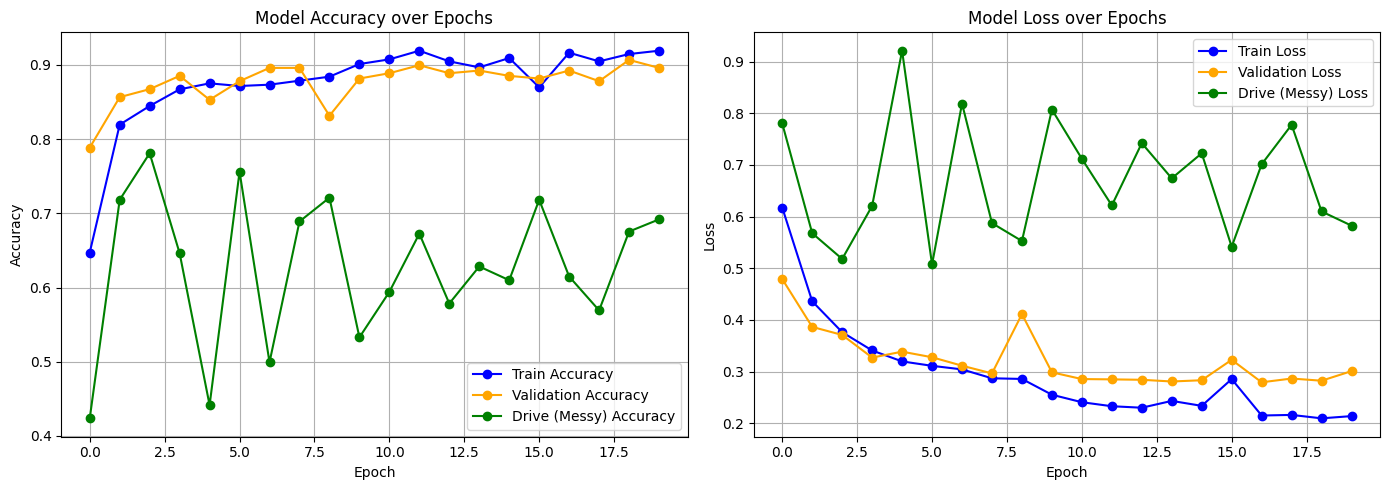

In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Accuracy
ax1.plot(history['train_acc'], label='Train Accuracy', color='blue', marker='o')
ax1.plot(history['val_acc'], label='Validation Accuracy', color='orange', marker='o')
ax1.plot(history['drive_acc'], label='Drive (Messy) Accuracy', color='green', marker='o')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

#Loss
ax2.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
ax2.plot(history['val_loss'], label='Validation Loss', color='orange', marker='o')
ax2.plot(history['drive_loss'], label='Drive (Messy) Loss', color='green', marker='o')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()